In [ ]:
import pandas as pd

#Carga de archivo masivo y verificación de información
df = pd.read_csv('data/dataset_original.csv', encoding='latin-1')

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


==== LIMPIEZA DE DATOS ====

In [ ]:
#Clasificar datos y obtener información pertinente
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


5000 Non-Null count en todo, por lo que no debería de haber vacíos

In [ ]:
#Confirmación de valores vacíos
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

No existen valores vacíos

In [ ]:
#Verificación de duplicados
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

#0 ==> no hay necesidad de eliminar nada

Número de filas duplicadas: 0


No hay duplicados, no es necesario eliminar nada

In [ ]:
#Convertir formato de fecha
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y')

#Verificación
print(df['order_date'].dtype)
df.head()

datetime64[us]


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


Formato de fecha correcto

In [ ]:
#Guardar dataset limpio
df.to_csv('data/dataset_limpio.csv', index=False)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


==== ANÁLISIS GRÁFICO ====

In [ ]:
ventas_por_categoria = df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)
#Utilizamos 'quantity' solamente para ver la venta de artículos, no ingresos

print(ventas_por_categoria)

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64


* Electrónicos son los más vendidos (35.15%)
* Belleza los ménos vendidos (14.81%)
* Artículos vendidos: 20,224


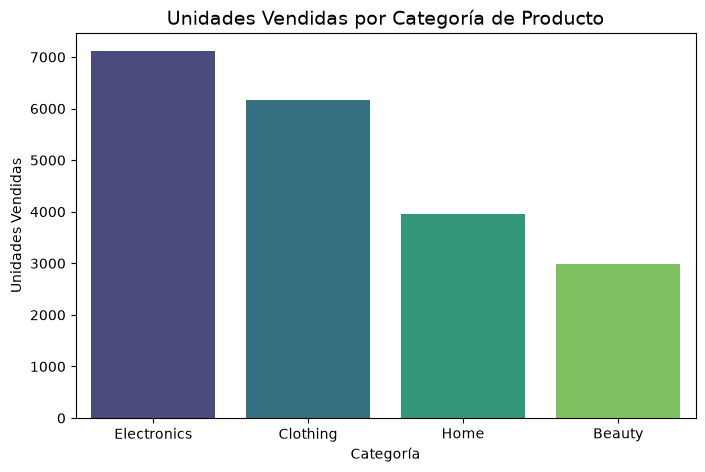

In [ ]:
#Gráfico de barras

import matplotlib.pyplot as plt
import seaborn as sns

# Dimensiones de gráfico (ancho, alto en pulgadas)
plt.figure(figsize=(8, 5))

# Creación del gráfico de barras (Seaborn)
sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, 
            hue=ventas_por_categoria.index, palette='viridis', legend=False)

#Título y etiquetas para claridad
plt.title('Unidades Vendidas por Categoría de Producto', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Unidades Vendidas')

# Mostramos el gráfico
plt.show()

region
West     5260
North    5164
East     4916
South    4884
Name: quantity, dtype: int64


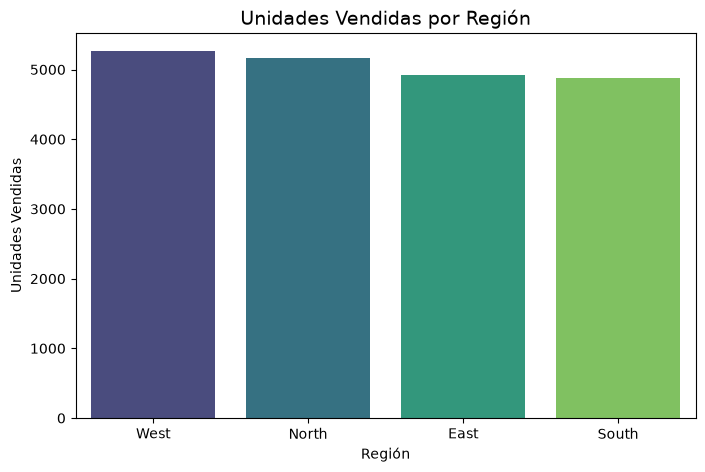

In [ ]:
#Análisis por región

ventas_por_region = df.groupby('region')['quantity'].sum().sort_values(ascending=False)
print(ventas_por_region)

# Dimensiones de gráfico
plt.figure(figsize=(8, 5))

# Creación de gráfico
sns.barplot(x=ventas_por_region.index, y=ventas_por_region.values, 
            hue=ventas_por_region.index, palette='viridis', legend=False)

# Título y etiquetas
plt.title('Unidades Vendidas por Región', fontsize=14)
plt.xlabel('Región')
plt.ylabel('Unidades Vendidas')

# ráfico
plt.show()

* La región 'West' es la que más vende - 5260 (26.01%)
* 'Sur' es la que menos vende - 4884 (24.15%)

Oeste: 26.01%
Norte: 25.53%
Este: 24.31%
Sur: 24.15%

* Diferencias muy pequeñas, no es necesario analizar más

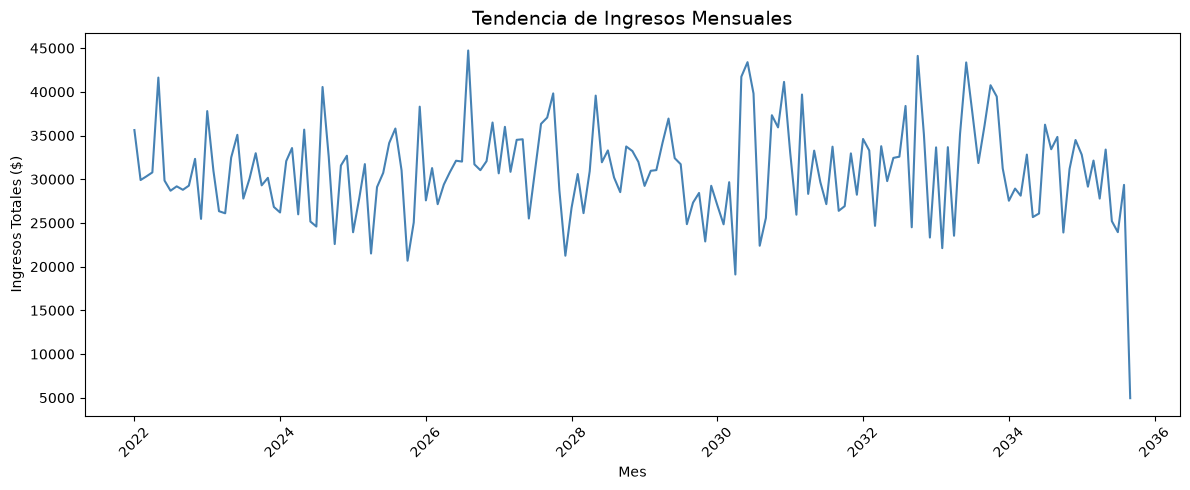

In [ ]:
#Gráfico tendencia de ventas por mes

# Columna auxiliar para establecer periodos de tiempo
df['periodo_mes'] = df['order_date'].dt.to_period('M')

# Ingresos totales por periodo de tiempo
ventas_mensuales = df.groupby('periodo_mes')['revenue'].sum()

# Formato de fecha correcto para el manejo de infromación
ventas_mensuales.index = ventas_mensuales.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, color='steelblue', linewidth=1.5)

plt.title('Tendencia de Ingresos Mensuales', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Ingresos Totales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Se dividieron los periodos de tiempo de manera clara para poder visualizar los picos a través del tiempo
* Existe una tendencia estable a lo largo del tiempo
* El pico al final solamente son las ventas de septiembre hasta el 9 de septiembre del 2035

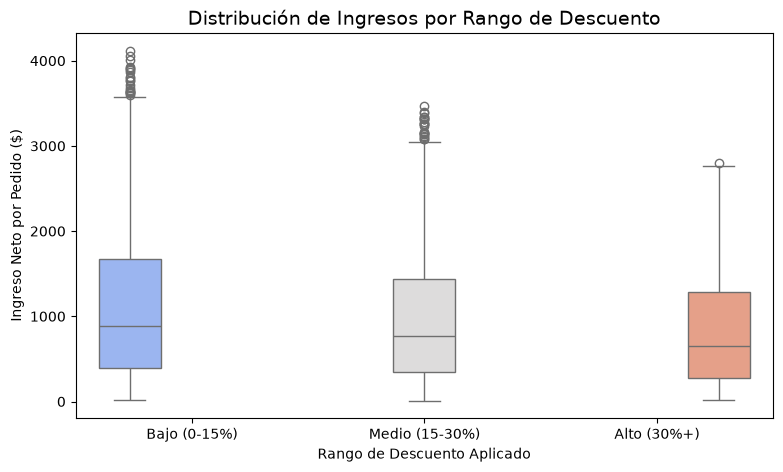

In [ ]:
#Gráfico de cajas para descuentos contra ingresos

#Rango de descuentos (Bajo-Medio-Alto)
df['rango_descuento'] = pd.cut(df['discount'], 
                                 bins=[0, 0.15, 0.30, 1.0], 
                                 labels=['Bajo (0-15%)', 'Medio (15-30%)', 'Alto (30%+)'])

plt.figure(figsize=(9, 5))
sns.boxplot(x='rango_descuento', y='revenue', data=df, hue='rango_descuento', 
            palette='coolwarm', legend=False)

plt.title('Distribución de Ingresos por Rango de Descuento', fontsize=14)
plt.xlabel('Rango de Descuento Aplicado')
plt.ylabel('Ingreso Neto por Pedido ($)')
plt.show()



* Se utilizaron los ingresos como un 'proxy' a la ganancia, dada una falta de datos pertinentes
* La mediana de cada agrupación de descuentos va bajando, indicando una posible tendencia a tener ingresos más bajos dado un descuento más alto.
* El comportamiento puede ser meramente matemático, ya que un descuento mayor implica menor 'precio percibido'
* La cantidad de "outliers" en los descuentos bajos demuestra que cuando hay descuentos menores al 15%, existen más pedidos abnormalmente altos, posible indicador de que descuentos altos no funcionan del todo


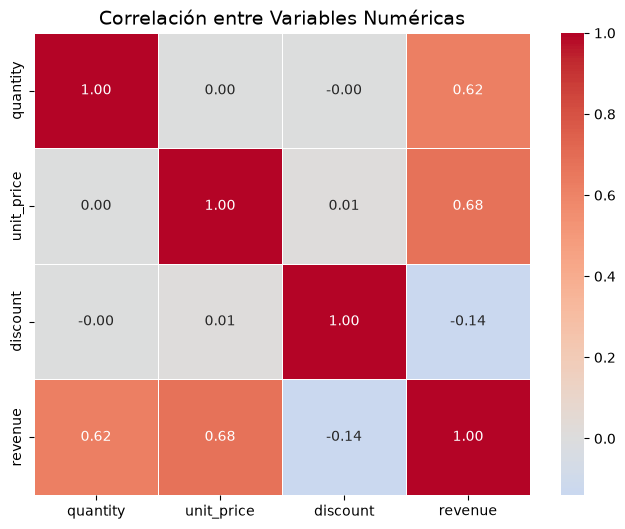

In [ ]:
#Heatmap para variables numéricas

#Columnas nuéricas necesarias
columnas_numericas = ['quantity', 'unit_price', 'discount', 'revenue']

matriz_correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, center=0)

plt.title('Correlación entre Variables Numéricas', fontsize=14)
plt.show()

* Se utilizaron solamente 4 variables numéricas para evitar confusiones y datos inecesarios
* Se ve una ligera correlación entre ingresos y cantidad, al igual que ingresos y precio
* El descuento parece tener una correlación negativa junto con los ingresos, es probable que estén afectando negativamente a las ventas